<a href="https://colab.research.google.com/github/rafiff18/2025_Pengolahan_Citra-_TI-2B/blob/main/js_4_segmentation_citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# - Muhammad Rafif Pasya
# - 4.33.23.1.18
# - TI-2B

Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu



nilai threshold otsu yang ditemukan :107


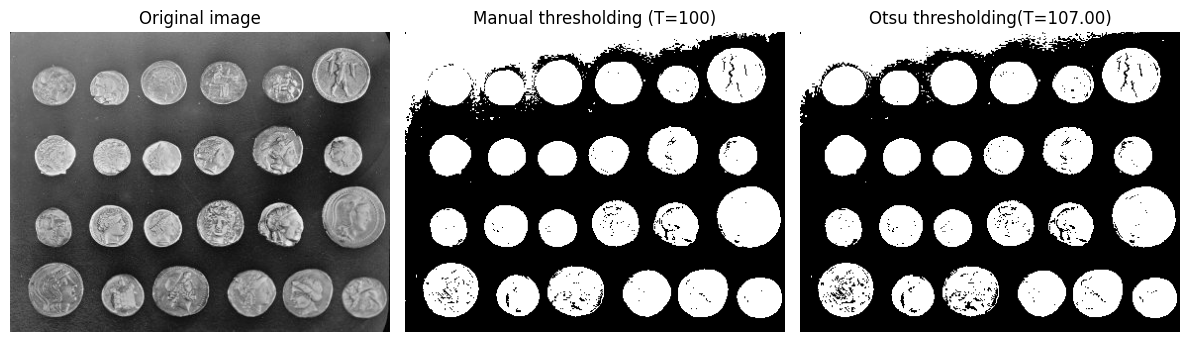

In [ ]:
import matplotlib.pyplot as plt
from skimage import data,filters,img_as_ubyte
from skimage.color import rgb2gray

image_coins=data.coins()
thresh_manual = 100
binnary_manual = image_coins > thresh_manual

thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

fig,axes = plt.subplots(ncols = 3,figsize = (12,4))
ax= axes.ravel()

ax[0].imshow(image_coins,cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(binnary_manual,cmap=plt.cm.gray)
ax[1].set_title(f'Manual thresholding (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu,cmap=plt.cm.gray)
ax[2].set_title(f'Otsu thresholding(T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show
print(f'nilai threshold otsu yang ditemukan :{thresh_otsu}')

Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)




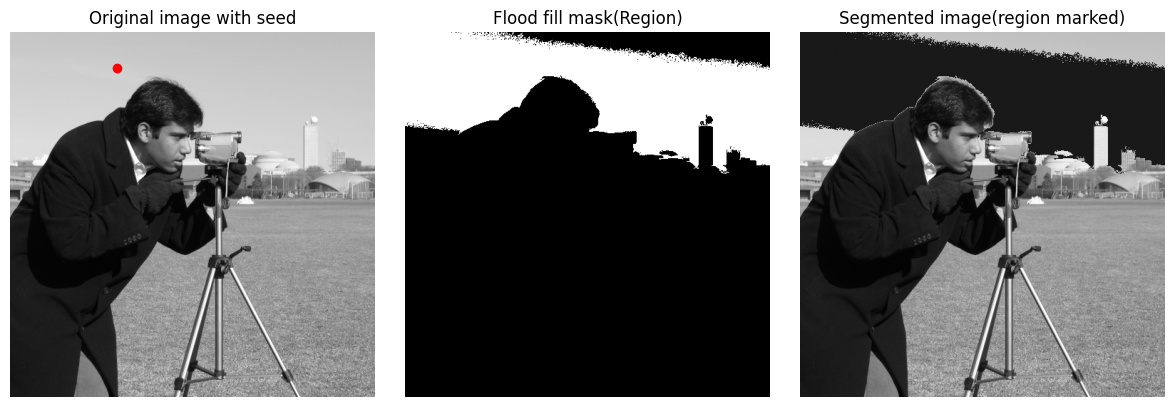

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data,segmentation,color

image_camera = data.camera()

seed_point = (50,150)

flood_mask = segmentation.flood(image_camera, seed_point,tolerance=10)
segmented_image = np.copy(image_camera)
segmented_image[flood_mask]=25

fig,axes = plt.subplots(ncols = 3,figsize = (12,4))
ax= axes.ravel()

ax[0].imshow(image_camera,cmap=plt.cm.gray)
ax[0].plot(seed_point[1],seed_point[0],'ro')
ax[0].set_title('Original image with seed')
ax[0].axis('off')

ax[1].imshow(flood_mask,cmap=plt.cm.gray)
ax[1].set_title('Flood fill mask(Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image,cmap=plt.cm.gray)
ax[2].set_title('Segmented image(region marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering


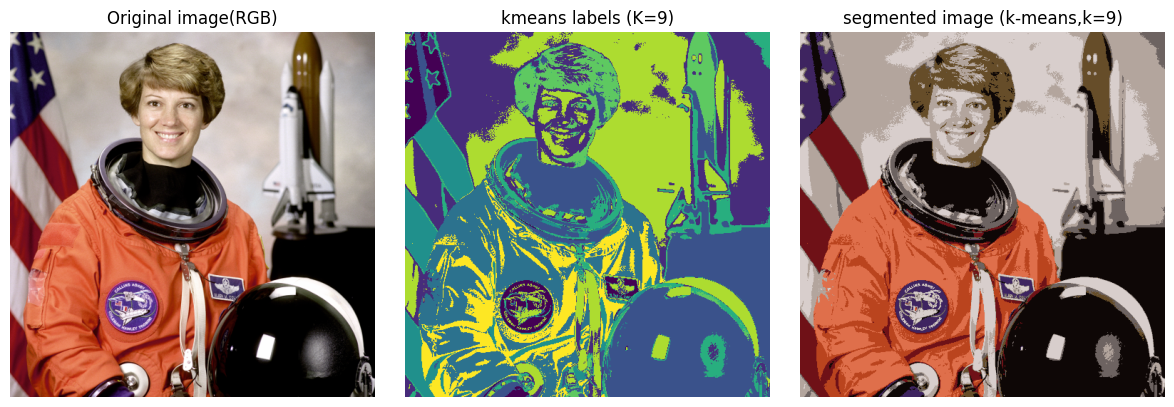

In [ ]:
from logging import warning
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab,lab2rgb
import warnings

image_astro = data.astronaut()
image_astro_float = image_astro.astype(float) /255.0

image_lab = rgb2lab(image_astro_float)
rows,cols,dims = image_lab.shape
pixel_features = image_lab.reshape(rows*cols,dims)

n_clusters = 9
kmeans = KMeans (n_clusters=n_clusters,random_state=0,n_init=10)
with warnings.catch_warnings():
  warnings.simplefilter("ignore")
  pixel_labels =kmeans.fit_predict(pixel_features)

segmented_labels = pixel_labels.reshape(rows,cols)

segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range (n_clusters):
  clusters_pixels =(pixel_labels ==k)
  mask_k = clusters_pixels.reshape(rows,cols)
  segmented_image_kmeans[mask_k] = centers_lab[k]

segmented_image_rgb = lab2rgb(segmented_image_kmeans)

fig,axes = plt.subplots(ncols = 3,figsize = (12,4))
ax= axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original image(RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'kmeans labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'segmented image (k-means,k={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed


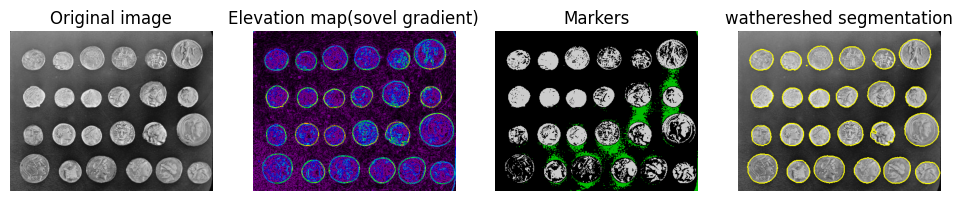

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data,filters,segmentation,morphology,measure
from scipy import ndimage as ndi

image_coins = data.coins()

elevation_map = filters.sobel(image_coins)

markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

segmentation_watershed = segmentation.watershed(elevation_map,markers)
segmentation_colored = segmentation.mark_boundaries(image_coins,segmentation_watershed)

fig,axes = plt.subplots(ncols = 4,figsize = (12,4))
ax= axes.ravel()

ax[0].imshow(image_coins,cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(elevation_map,cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation map(sovel gradient)')
ax[1].axis('off')

ax[2].imshow(markers,cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmentation_colored)
ax[3].set_title('wathereshed segmentation')
ax[3].axis('off')
plt.imshow(segmentation_colored)
plt.show()

Praktikum 5. Perbandingan Visual Hasil Segmentasi


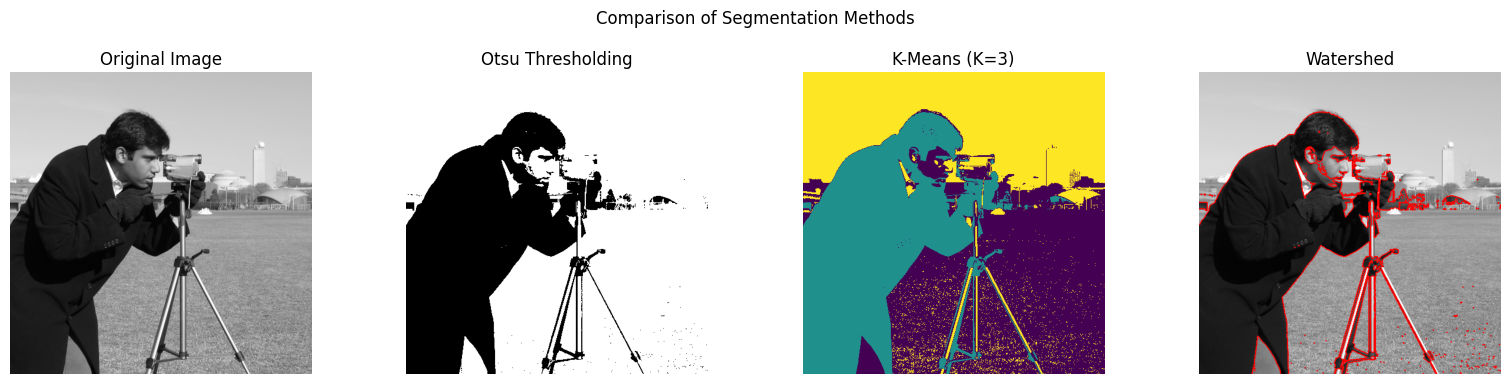

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

image = data.camera()
image_float = img_as_float(image)

thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1, 0, 0))
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


3.	Eksperimen Thresholding

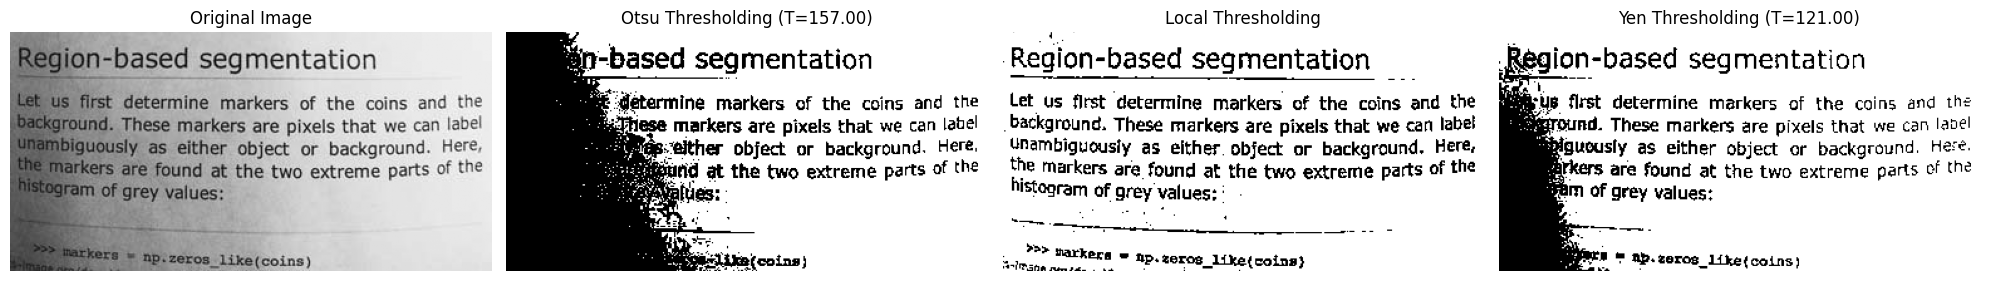

In [2]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray


image_page = data.page()
# Otsu thresholding
thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# Local thresholding
block_size = 25
local_thresh = filters.threshold_local(image_page, block_size, offset=10)
binary_local = image_page > local_thresh

# Yen thresholding
thresh_yen = filters.threshold_yen(image_page)
binary_yen = image_page > thresh_yen

# Tampilkan hasil
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ax = axes.ravel()

ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title(f'Otsu Thresholding (T={thresh_otsu:.2f})')
ax[1].axis('off')

ax[2].imshow(binary_local, cmap=plt.cm.gray)
ax[2].set_title('Local Thresholding')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap=plt.cm.gray)
ax[3].set_title(f'Yen Thresholding (T={thresh_yen:.2f})')
ax[3].axis('off')

plt.tight_layout()
plt.show()


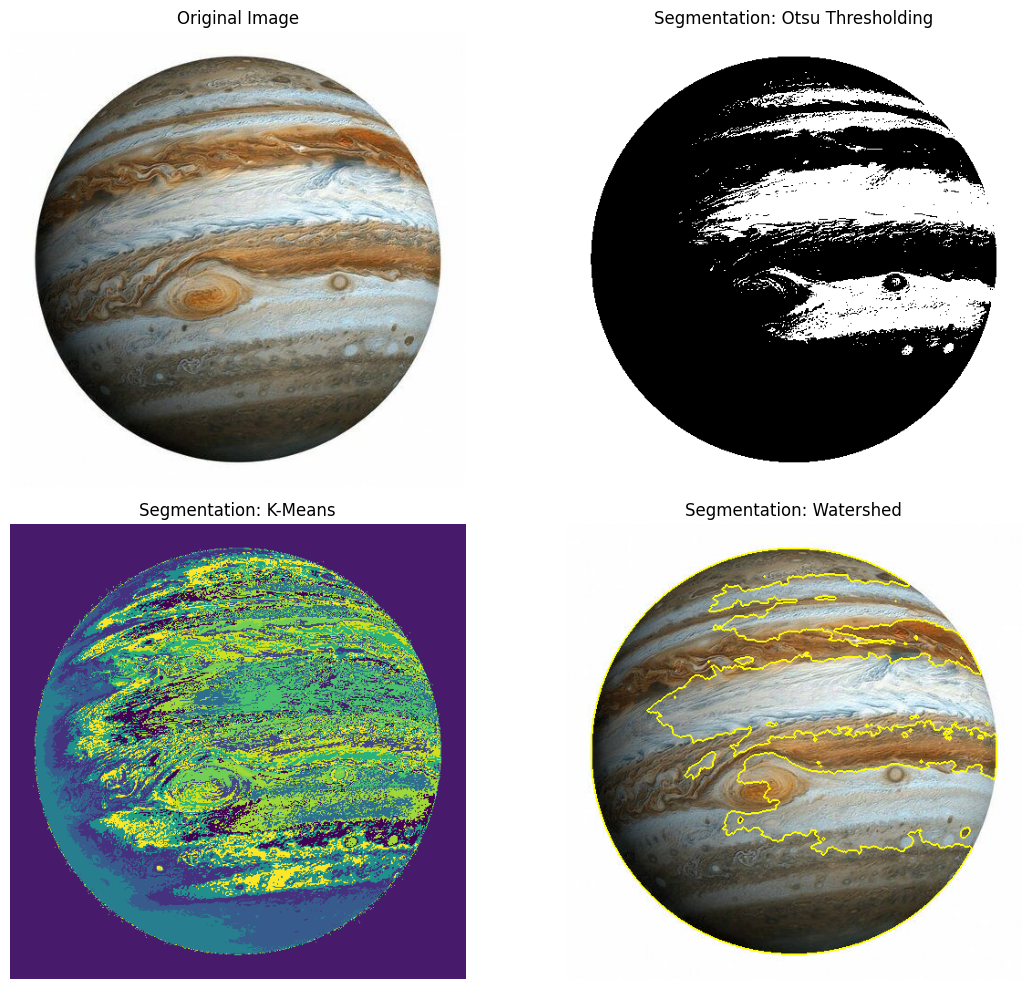

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, segmentation, morphology
from sklearn.cluster import KMeans
from scipy import ndimage as ndi

# Baca gambar
image = io.imread('/content/download (1).jpg')
image_gray = color.rgb2gray(image)

# ---------------------
# 1. Segmentasi dengan Otsu
# ---------------------
thresh_otsu = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh_otsu

# ---------------------
# 2. Segmentasi dengan K-Means
# ---------------------
rows, cols, dims = image.shape
image_reshape = image.reshape(rows*cols, dims)
kmeans = KMeans(n_clusters=15, random_state=0, n_init=10)
labels = kmeans.fit_predict(image_reshape)
segmented_kmeans = labels.reshape(rows, cols)

# ---------------------
# 3. Segmentasi dengan Watershed
# ---------------------
elevation_map = filters.sobel(image_gray)
markers = np.zeros_like(image_gray, dtype=np.int32)
markers[image_gray < 0.3] = 1
markers[image_gray > 0.7] = 2

# Convert elevation_map to the correct data type if necessary
elevation_map = elevation_map.astype(np.float64)

segmentation_watershed = segmentation.watershed(elevation_map, markers)
watershed_boundary = segmentation.mark_boundaries(image, segmentation_watershed)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax = axes.ravel()

ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Segmentation: Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title('Segmentation: K-Means')
ax[2].axis('off')

ax[3].imshow(watershed_boundary)
ax[3].set_title('Segmentation: Watershed')
ax[3].axis('off')

plt.tight_layout()
plt.show()